---
# Generative Adversarial Networks
---

In this exercise, we will implement a generative model called a **Generative Adversarial Network (GAN)** and apply it to the AFHQ Cat dataset.

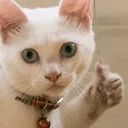

A GAN consists of two networks: a generator and a discriminator. The generator learns to create synthetic images from random latent vectors, while the discriminator learns to distinguish real images from generated ones. Through this adversarial training process, the generator gradually learns to produce more realistic cat images.

You do not need to read the paper to complete the exercise, but it gives useful background on adversarial training and the original GAN objective.  
Paper: [Generative Adversarial Networks](https://arxiv.org/abs/1406.2661)

---
# Imports
---

Run the code cell below after you have set up everything correctly (either locally or in Colab).

In [1]:
import torch
import importlib
import data
import trainer
import tests
import visual
import models
import utils

---
## Load and Visualize the Input Images
---

Instead of CIFAR-10, we use the AFHQ Cat dataset. CIFAR-10 contains many different object classes and its cat images are very low-resolution and visually diverse, which makes the generation task unnecessarily difficult for this small generator setup. AFHQ Cats is better suited for learning a focused cat image distribution.

When `make_afhq_loaders` is called for the first time, the AFHQ dataset is downloaded and extracted. The cat images are then resized to the requested `image_size` and cached in a separate folder such as `afhq_v2_32/`. On later runs, this resized cache is reused. Finally, the resized cat images are loaded into memory as normalized tensors, which avoids repeatedly decoding and resizing the original high-resolution images during training.

Before training the model, we inspect a few validation images to verify that the data is loaded, resized, normalized, and batched correctly.

**Note:** After finishing the exercise, you can experiment with a higher `image_size` (e.g., 64 or 128) to see how the model performs on higher-resolution images. However, this will require more GPU memory and training time. You can also change the class name to `"dog"` or `"wild"` to train the model on different animal classes.

In [2]:
_, val_loader, _ = data.make_afhq_loaders(batch_size=8, num_workers=0, image_size=32)
x_true, _ = next(iter(val_loader))

visual._image_grid(x_true, title="AFHQ Cat validation images").show()

AFHQ raw dir: /data/afhq_v2
AFHQ resized dir: /data/afhq_v2_32
AFHQ image size: 32x32
AFHQ cat train: 5065
AFHQ cat val: 246
AFHQ cat test: 247


---
## Theory
---

A Generative Adversarial Network consists of a generator $G$ and a discriminator $D$ network.

The generator samples a latent vector $z \sim \mathcal{N}(0, I)$ and maps it to a generated image $\hat{x} = G(z)$.

The discriminator receives either a real image $x$ or a fake image $\hat{x}$ and outputs a logit $s = D(x)$, indicating whether the image looks real or fake.

During training, the discriminator learns to classify real images as real and generated images as fake:
$$D(x) \rightarrow 1, \quad D(G(z)) \rightarrow 0.$$
The generator learns the opposite: it tries to fool the discriminator by making generated images look real:
$$D(G(z)) \rightarrow 1.$$

---
## Generator and Discriminator
---

## **Task:**

Copy your solution from `./11a-vae/models.py` and adapt them for GAN training in `models.py`. Implement a `Generator` class that maps latent vectors of shape `(B, latent_dim)` to images of shape `(B, 3, 32, 32)`, and a `Discriminator` class that maps images of shape `(B, 3, 32, 32)` to logits of shape `(B, 1)`.

**Hints:**
- The discriminator should use a sigmoid activation function at the output layer to produce probabilities.
- The last generator activation function should be Tanh, so that these images are in a normalized range like the real images.

In [3]:
importlib.reload(tests)
importlib.reload(models)
tests.test_gan_models()

✅ PASS: GAN Generator/Discriminator models look correct.


True

---

## GAN Loss

---

The GAN is trained as a two-player minimax game between a generator $G$ and a discriminator $D$:
$$\min_G \max_D \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim \mathcal{N}(0, I)}[\log(1 - D(G(z)))].$$

The discriminator is trained to classify real images as real and generated images as fake. The generator is trained to fool the discriminator, i.e. to make generated images look real.

For binary classification with logits, we use the binary cross-entropy loss
$$\ell(p, y) = - y \log(p) - (1-y)\log(1-p),$$
where $p$ is the discriminator output (probability), $y \in \{0,1\}$ is the target labeln.

The batch loss is the mean over all samples in the batch.

## **Task:**

Implement `gan_criterion` in `trainer.py`.

**Hints:**
- Do not use `torch.nn.functional.binary_cross_entropy`.


In [4]:
importlib.reload(tests)
importlib.reload(trainer)
tests.test_gan_criterion()

✅ PASS: GAN criterion is correct.


True

---
## GAN Training Step
---
The discriminator and generator are trained in alternating steps. In the discriminator step, we compute the loss for real and fake images and update the discriminator parameters:
$$
\begin{aligned}
& \max_D \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim \mathcal{N}(0, I)}[\log(1 - D(G(z)))] \\
\Leftrightarrow \quad & \min_D \mathbb{E}_{x \sim p_{data}}[-\log D(x)] + \mathbb{E}_{z \sim \mathcal{N}(0, I)}[-\log(1 - D(G(z)))]
\end{aligned}
$$

In the generator step, we compute the loss for generated images and update the generator parameters:
$$\min_G \mathbb{E}_{z \sim \mathcal{N}(0, I)}[\log (1-D(G(z)))]$$
From the lecture, we know that it is better to use the non-saturating loss for the generator:
$$\min_G \mathbb{E}_{z \sim \mathcal{N}(0, I)}[- \log D(G(z))]$$

## **Task:**
Implement `_step` in `trainer.py`.

**Hints:**
- If an optimizer is given, perform a training step with parameter updates. Otherwise, run an evaluation step without gradient computation. [This function](https://docs.pytorch.org/docs/2.12/generated/torch.autograd.grad_mode.set_grad_enabled.html) might be useful for this.

In [5]:
importlib.reload(tests)
importlib.reload(trainer)
tests.test_gan_step()

✅ PASS: GAN _step is correct.


True

---
## GAN Training Loop
---

We now want to train the GAN on AFHQ. We will ignore the original class labels. The model only learns to reconstruct images and organize the latent space.

In 'trainer.py', we have a training loop skeleton. `_loop` should run one full epoch over a data loader, call `_step` for each batch, and return the average `gen_loss`, `disc_loss`, `disc_loss_real`, and `disc_loss_fake` over all samples. `train_gan` should create the AFHQ data loaders, initialize the GAN and optimizer, train for the given number of epochs, and store training and validation metrics in `history`.

## **Task:**
Implement `_loop` and `train_gan` in `trainer.py`.

In [7]:
importlib.reload(tests)
importlib.reload(trainer)
importlib.reload(models)

############################################
# TODO: Hyperparameters. Adjust these values to tune training.

latent_dim = 128           # The dimensionality of the latent space.
gen_lr = 2e-4             # The learning rate for the generator.
disc_lr = 5e-5              # The learning rate for the discriminator.
betas= (0.5, 0.999)                # The beta parameters for the Adam optimizer.
batch_size = 64           # The number of samples per batch.
epochs =   200             # The number of epochs to train for.
image_size =   32         # The size of the images (height and width).
num_workers = 2          # The number of worker threads for data loading.

############################################

device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built() else "cpu")
print(f"Using device: {device}")

gen, disc, history = trainer.train_gan(
    batch_size=batch_size,
    latent_dim=latent_dim,
    gen_lr=gen_lr,
    disc_lr=disc_lr,
    betas=betas,
    epochs=epochs,
    device=device,
    image_size=image_size,
    num_workers=num_workers,
)

visual.show_training_stats(
    history,
    title="GAN Training",
).show()

Using device: cuda:0
AFHQ raw dir: /data/afhq_v2
AFHQ resized dir: /data/afhq_v2_32
AFHQ image size: 32x32
AFHQ cat train: 5065
AFHQ cat val: 246
AFHQ cat test: 247


---
## Sampling New Images
---

A trained GAN can generate new images by sampling latent vectors from a standard normal distribution.

In [8]:
gen.eval()
x_fake = gen.sample(x_true.shape[0], device=device)

visual._image_grid(torch.cat([x_true.cpu(), x_fake.cpu()]), title="Top: Real\nBottom: Fake", cols=8).show()